# Distribuição Gaussiana para 1000 eventos

Total de eventos gerados: 10000
Média calculada: 1869.00
Desvio padrão calculado: 10.01
Valor mínimo: 1832.11 | Valor máximo: 1911.40


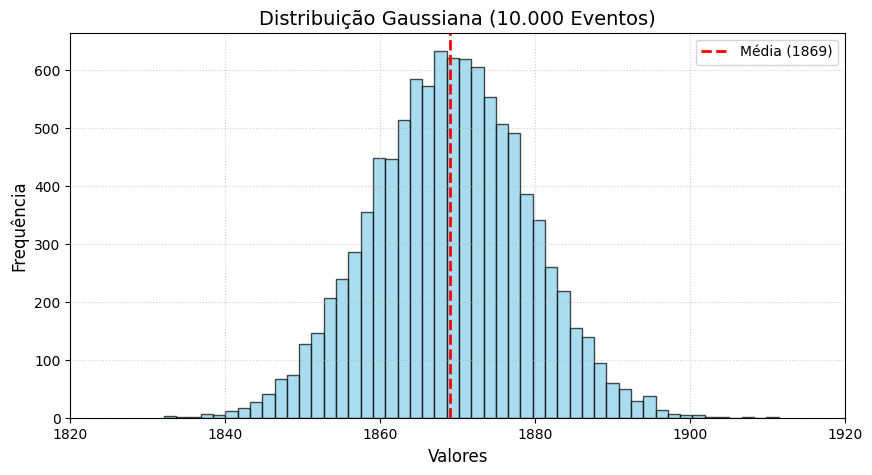

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuração dos parâmetros
media = 1869          # Centro da distribuição
desvio_padrao = 10    # Largura (sigma)
n_eventos = 10000     # Quantidade desejada de eventos
limite_inf = 1820     # Limite inferior
limite_sup = 1920     # Limite superior

# 2. Geração dos dados
# Geramos uma quantidade levemente maior para garantir exatamente 10.000 pontos após a filtragem
amostras = np.random.normal(loc=media, scale=desvio_padrao, size=int(n_eventos * 1.1))

# Filtrando os valores dentro do intervalo [1820, 1920] e pegando exatamente 10.000
dados = amostras[(amostras >= limite_inf) & (amostras <= limite_sup)][:n_eventos]

# 3. Exibição de estatísticas básicas no console
print(f"Total de eventos gerados: {len(dados)}")
print(f"Média calculada: {dados.mean():.2f}")
print(f"Desvio padrão calculado: {dados.std():.2f}")
print(f"Valor mínimo: {dados.min():.2f} | Valor máximo: {dados.max():.2f}")

# 4. Plotagem do gráfico
plt.figure(figsize=(10, 5))
plt.hist(dados, bins=50, color='skyblue', edgecolor='black', alpha=0.7, density=False)

# Adicionando linha indicativa da média
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média ({media})')

# Personalização do gráfico
plt.title('Distribuição Gaussiana (10.000 Eventos)', fontsize=14)
plt.xlabel('Valores', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.xlim(limite_inf, limite_sup)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Exibir gráfico no Colab
plt.show()

# Ajuste de Sinal (Gaussiana) + Fundo (Exponencial)

RESULTADOS DO FIT E COMPARAÇÃO COM VALORES VERDADEIROS
N_sinal        : Ajustado =  10100.805 ± 151.678 | Real =  10000.000 | Desvio = +0.66σ
Massa (mu)     : Ajustado =   1868.953 ±   0.147 | Real =   1869.000 | Desvio = -0.32σ
Largura (sigma): Ajustado =     10.089 ±   0.145 | Real =     10.000 | Desvio = +0.61σ
N_fundo        : Ajustado =   9801.304 ± 150.687 | Real =  10000.000 | Desvio = -1.32σ
Slope (fundo)  : Ajustado =     -0.002 ±   0.000 | Real =     -0.003 | Desvio = +2.95σ


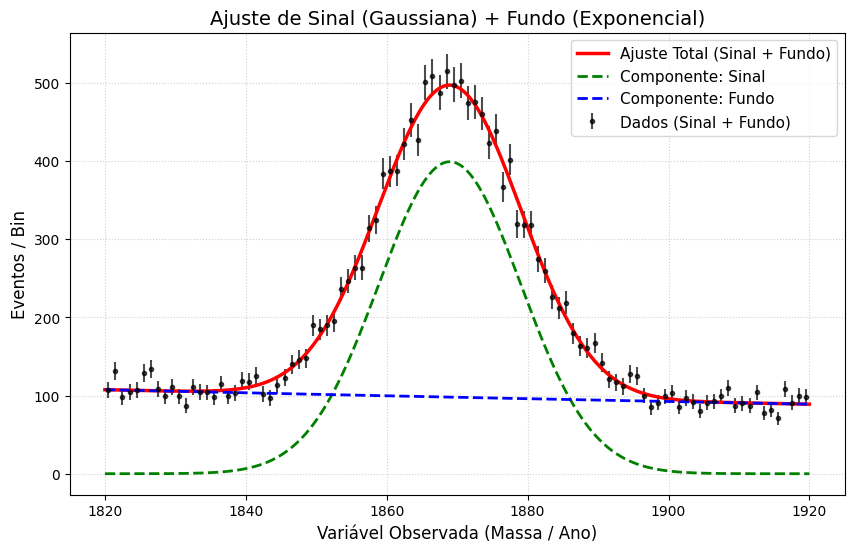

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

# Fixar a semente para reprodutibilidade (opcional)
np.random.seed(42)

# --- 1. PARÂMETROS DE ENTRADA ---
xmin, xmax = 1820, 1920
N_sig_true = 10000
N_bg_true = 10000
mu_true = 1869.0
sigma_true = 10.0
slope_true = -0.003

# --- 2. GERAÇÃO DOS DADOS ---
# Sinal: Gaussiana
sig_raw = np.random.normal(mu_true, sigma_true, size=int(N_sig_true * 1.1))
sig_data = sig_raw[(sig_raw >= xmin) & (sig_raw <= xmax)][:N_sig_true]

# Fundo: Exponencial no intervalo [xmin, xmax] via Transformada Inversa
u = np.random.uniform(0, 1, size=int(N_bg_true * 1.1))
exp_min, exp_max = np.exp(slope_true * xmin), np.exp(slope_true * xmax)
bg_raw = np.log(exp_min + u * (exp_max - exp_min)) / slope_true
bg_data = bg_raw[(bg_raw >= xmin) & (bg_raw <= xmax)][:N_bg_true]

# Amostra Combinada
dados_totais = np.concatenate([sig_data, bg_data])

# --- 3. DEFINIÇÃO DAS PDFs NORMALIZADAS E MODELO DE FIT ---
nbins = 100
counts, bin_edges = np.histogram(dados_totais, bins=nbins, range=(xmin, xmax))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = (xmax - xmin) / nbins

def pdf_gaussian(x, mu, sigma):
    """PDF Gaussiana normalizada no intervalo [xmin, xmax]"""
    norm = 0.5 * (erf((xmax - mu) / (sigma * np.sqrt(2))) - erf((xmin - mu) / (sigma * np.sqrt(2))))
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2) / norm

def pdf_exponential(x, slope):
    """PDF Exponencial normalizada no intervalo [xmin, xmax]"""
    norm = (np.exp(slope * xmax) - np.exp(slope * xmin)) / slope
    return np.exp(slope * x) / norm

def fit_model(x, n_sig, mu, sigma, n_bg, slope):
    """Modelo total ajustado ao número de eventos por bin"""
    return bin_width * (n_sig * pdf_gaussian(x, mu, sigma) + n_bg * pdf_exponential(x, slope))

# --- 4. EXECUÇÃO DO FIT ---
# Chutes iniciais para os parâmetros
p0 = [9000, 1870, 12, 11000, -0.005]
# Erros poissonianos por bin (sigma = sqrt(N))
y_err = np.sqrt(np.maximum(counts, 1))

popt, pcov = curve_fit(fit_model, bin_centers, counts, p0=p0, sigma=y_err, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

# --- 5. EXIBIÇÃO DOS RESULTADOS ---
print("="*60)
print("RESULTADOS DO FIT E COMPARAÇÃO COM VALORES VERDADEIROS")
print("="*60)
nomes = ["N_sinal", "Massa (mu)", "Largura (sigma)", "N_fundo", "Slope (fundo)"]
trues = [N_sig_true, mu_true, sigma_true, N_bg_true, slope_true]

for name, val, err, true_val in zip(nomes, popt, perr, trues):
    pull = (val - true_val) / err
    print(f"{name:15s}: Ajustado = {val:10.3f} ± {err:7.3f} | Real = {true_val:10.3f} | Desvio = {pull:+.2f}σ")

# --- 6. PLOTAGEM DO GRÁFICO ---
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, counts, yerr=y_err, fmt='o', color='black', label='Dados (Sinal + Fundo)', markersize=3, alpha=0.7)

x_dense = np.linspace(xmin, xmax, 500)
plt.plot(x_dense, fit_model(x_dense, *popt), 'r-', linewidth=2.5, label='Ajuste Total (Sinal + Fundo)')
plt.plot(x_dense, bin_width * popt[0] * pdf_gaussian(x_dense, popt[1], popt[2]), 'g--', linewidth=2, label='Componente: Sinal')
plt.plot(x_dense, bin_width * popt[3] * pdf_exponential(x_dense, popt[4]), 'b--', linewidth=2, label='Componente: Fundo')

plt.title('Ajuste de Sinal (Gaussiana) + Fundo (Exponencial)', fontsize=14)
plt.xlabel('Variável Observada (Massa / Ano)', fontsize=12)
plt.ylabel('Eventos / Bin', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

# Integração de x³ por Monte Carlo

Estimativa de Monte Carlo: 0.248170
Valor exato:              0.250000
Erro absoluto:            0.001830


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


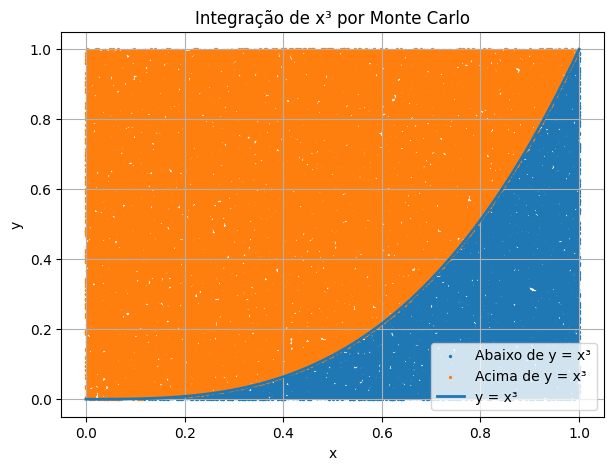

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Número de pontos
N = 100000

# Gera pontos aleatórios
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

# Verifica quais pontos estão abaixo da curva y = x^3
pontos_abaixo = y <= x**3

# Estimativa da integral
integral = np.sum(pontos_abaixo) / N

print(f"Estimativa de Monte Carlo: {integral:.6f}")
print(f"Valor exato:              {1/4:.6f}")
print(f"Erro absoluto:            {abs(integral - 1/4):.6f}")

# Gráfico
plt.figure(figsize=(7, 5))

# Pontos abaixo da curva
plt.scatter(
    x[pontos_abaixo],
    y[pontos_abaixo],
    s=2,
    label="Abaixo de y = x³"
)

# Pontos acima da curva
plt.scatter(
    x[~pontos_abaixo],
    y[~pontos_abaixo],
    s=2,
    label="Acima de y = x³"
)

# Curva
x_curve = np.linspace(0, 1, 500)
plt.plot(x_curve, x_curve**3, linewidth=2, label="y = x³")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Integração de x³ por Monte Carlo")
plt.legend()
plt.grid()

plt.show()

Estimativa de $\\pi$ por Monte Carlo

Total de pontos gerados: 100,000
Pontos dentro do círculo: 78,440
Valor estimado de π: 3.137600
Valor real de π:     3.141593
Erro relativo:       0.1271%


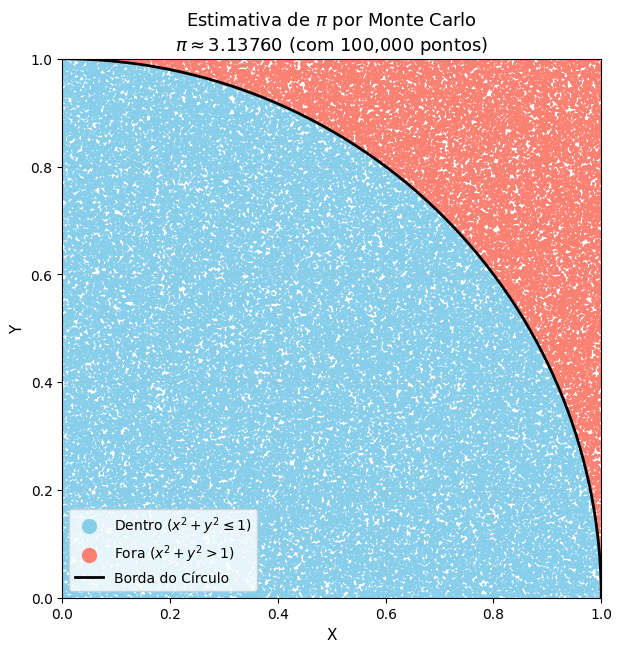

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurações
n_pontos = 100_000  # Quantidade de pontos sorteados

# 2. Gerar coordenadas aleatórias (x, y) no intervalo [0, 1]
np.random.seed(42)  # Para reprodutibilidade
x = np.random.uniform(0, 1, n_pontos)
y = np.random.uniform(0, 1, n_pontos)

# 3. Condição para estar dentro do círculo: x^2 + y^2 <= 1
dentro = (x**2 + y**2) <= 1
n_dentro = np.sum(dentro)

# 4. Cálculo da estimativa de Pi
pi_estimado = 4 * (n_dentro / n_pontos)
erro_relativo = abs(pi_estimado - np.pi) / np.pi * 100

# 5. Exibição dos resultados numéricos
print("=" * 40)
print(f"Total de pontos gerados: {n_pontos:,}")
print(f"Pontos dentro do círculo: {n_dentro:,}")
print(f"Valor estimado de π: {pi_estimado:.6f}")
print(f"Valor real de π:     {np.pi:.6f}")
print(f"Erro relativo:       {erro_relativo:.4f}%")
print("=" * 40)

# 6. Visualização Gráfica
fig, ax = plt.subplots(figsize=(7, 7))

# Trocado \le por \leq para compatibilidade com o Matplotlib
ax.scatter(x[dentro], y[dentro], color='skyblue', s=1, label=r'Dentro ($x^2 + y^2 \leq 1$)')
ax.scatter(x[~dentro], y[~dentro], color='salmon', s=1, label=r'Fora ($x^2 + y^2 > 1$)')

# Desenhar o arco do círculo
theta = np.linspace(0, np.pi/2, 200)
ax.plot(np.cos(theta), np.sin(theta), color='black', linewidth=2, label='Borda do Círculo')

# Título com comandos LaTeX ajustados
ax.set_title(f'Estimativa de $\\pi$ por Monte Carlo\n$\\pi \\approx {pi_estimado:.5f}$ (com {n_pontos:,} pontos)', fontsize=13)
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)

# Ajustes de eixos e proporção
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend(loc='lower left', markerscale=10)
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

# Diagrama de Dalitz F.H.

Sucesso! Gerados 10000 eventos dentro do contorno cinemático.


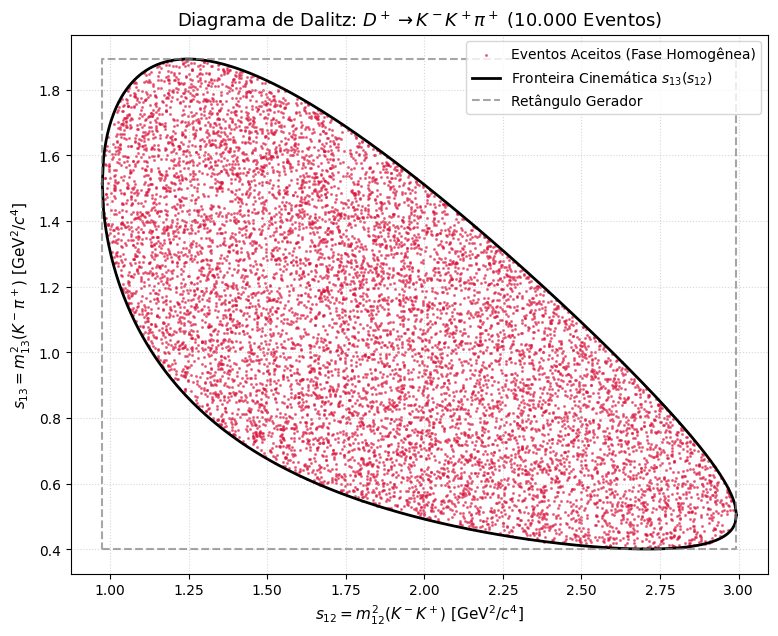

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. MASSAS DOS PARÂMETROS (em GeV/c^2) ---
M  = 1.86966   # D+
m1 = 0.49368   # K-  (Partícula 1)
m2 = 0.49368   # K+  (Partícula 2)
m3 = 0.13957   # pi+ (Partícula 3)

# --- 2. LIMITES DO RETÂNGULO GERADOR (CAIXA) ---
s12_min = (m1 + m2)**2
s12_max = (M - m3)**2

s13_min_box = (m1 + m3)**2
s13_max_box = (M - m2)**2

# --- 3. FUNÇÃO QUE CALCULA OS LIMITES CINEMÁTICOS s13(s12) ---
def get_s13_bounds(s12, M, m1, m2, m3):
    """Retorna (s13_low, s13_up) para um ou mais valores de s12."""
    E1_star = (s12 + m1**2 - m2**2) / (2.0 * np.sqrt(s12))
    E3_star = (M**2 - s12 - m3**2) / (2.0 * np.sqrt(s12))

    # Tolerância numérica contra valores negativos por arredondamento
    p1_star = np.sqrt(np.maximum(0.0, E1_star**2 - m1**2))
    p3_star = np.sqrt(np.maximum(0.0, E3_star**2 - m3**2))

    s13_low = m1**2 + m3**2 + 2.0 * E1_star * E3_star - 2.0 * p1_star * p3_star
    s13_up  = m1**2 + m3**2 + 2.0 * E1_star * E3_star + 2.0 * p1_star * p3_star

    return s13_low, s13_up

# --- 4. GERAÇÃO MONTE CARLO (ACEITAÇÃO E REJEIÇÃO) ---
n_eventos_desejados = 10000
s12_aceitos = []
s13_aceitos = []

np.random.seed(42)

# Laço de geração vetorial para eficiência
while len(s12_aceitos) < n_eventos_desejados:
    # Gerar lote de pontos uniformes dentro do retângulo
    lote = (n_eventos_desejados - len(s12_aceitos)) * 3
    s12_cand = np.random.uniform(s12_min, s12_max, lote)
    s13_cand = np.random.uniform(s13_min_box, s13_max_box, lote)

    # Obter limites cinemáticos para cada s12 sorteado
    s13_low, s13_up = get_s13_bounds(s12_cand, M, m1, m2, m3)

    # Condição de aceitação: s13 dentro dos limites da fronteira
    mascara = (s13_cand >= s13_low) & (s13_cand <= s13_up)

    s12_aceitos.extend(s12_cand[mascara])
    s13_aceitos.extend(s13_cand[mascara])

# Reduzir exatamente ao número solicitado
s12_aceitos = np.array(s12_aceitos[:n_eventos_desejados])
s13_aceitos = np.array(s13_aceitos[:n_eventos_desejados])

print(f"Sucesso! Gerados {len(s12_aceitos)} eventos dentro do contorno cinemático.")

# --- 5. PLOTAGEM DO GRÁFICO DE DALITZ ---
fig, ax = plt.subplots(figsize=(9, 7))

# Plotar os pontos aceitos
ax.scatter(s12_aceitos, s13_aceitos, color='crimson', s=1.5, alpha=0.5, label='Eventos Aceitos (Fase Homogênea)')

# Desenhar a curva limite teórica
s12_grid = np.linspace(s12_min + 1e-6, s12_max - 1e-6, 500)
s13_low_grid, s13_up_grid = get_s13_bounds(s12_grid, M, m1, m2, m3)

ax.plot(s12_grid, s13_low_grid, 'k-', linewidth=2, label='Fronteira Cinemática $s_{13}(s_{12})$')
ax.plot(s12_grid, s13_up_grid, 'k-', linewidth=2)

# Desenhar a caixa do gerador
ax.plot([s12_min, s12_max, s12_max, s12_min, s12_min],
        [s13_min_box, s13_min_box, s13_max_box, s13_max_box, s13_min_box],
        '--', color='gray', alpha=0.7, label='Retângulo Gerador')

ax.set_title(r'Diagrama de Dalitz: $D^+ \to K^- K^+ \pi^+$ (10.000 Eventos)', fontsize=13)
ax.set_xlabel(r'$s_{12} = m_{12}^2 (K^- K^+)$ [$\mathrm{GeV}^2/c^4$]', fontsize=11)
ax.set_ylabel(r'$s_{13} = m_{13}^2 (K^- \pi^+)$ [$\mathrm{GeV}^2/c^4$]', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

# Diagrama de Dalitz e Projeção no eixo s13 com Ressonância $K^*(892)^0$'

Sucesso! 10000 eventos gerados com o perfil de ressonância K*(892).


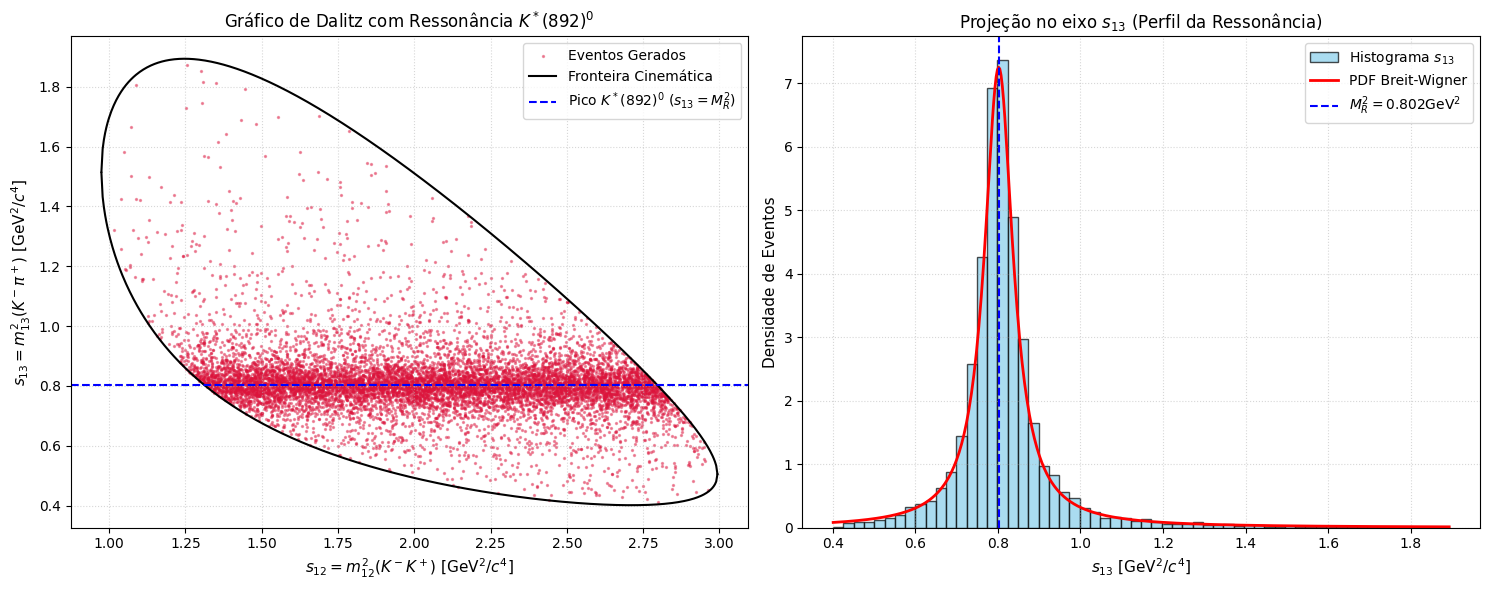

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. MASSAS DOS PARÂMETROS (em GeV/c^2) ---
M  = 1.86966   # D+
m1 = 0.49368   # K-  (1)
m2 = 0.49368   # K+  (2)
m3 = 0.13957   # pi+ (3)

# Parâmetros PDG para K*(892)0 -> K- pi+
M_R     = 0.89555   # GeV/c^2
Gamma_R = 0.0473    # GeV

# --- 2. LIMITES DO RETÂNGULO GERADOR ---
s12_min = (m1 + m2)**2
s12_max = (M - m3)**2
s13_min_box = (m1 + m3)**2
s13_max_box = (M - m2)**2

def get_s13_bounds(s12, M, m1, m2, m3):
    """Limites cinemáticos s13(s12)"""
    E1_star = (s12 + m1**2 - m2**2) / (2.0 * np.sqrt(s12))
    E3_star = (M**2 - s12 - m3**2) / (2.0 * np.sqrt(s12))

    p1_star = np.sqrt(np.maximum(0.0, E1_star**2 - m1**2))
    p3_star = np.sqrt(np.maximum(0.0, E3_star**2 - m3**2))

    s13_low = m1**2 + m3**2 + 2.0 * E1_star * E3_star - 2.0 * p1_star * p3_star
    s13_up  = m1**2 + m3**2 + 2.0 * E1_star * E3_star + 2.0 * p1_star * p3_star
    return s13_low, s13_up

# --- 3. AMPLITUDE COMPLEXA BREIT-WIGNER E PDF ---
def bw_amplitude(s13, M_R, Gamma_R):
    """Amplitude Breit-Wigner complexa com largura constante"""
    return 1.0 / (s13 - M_R**2 + 1j * M_R * Gamma_R)

def bw_pdf(s13, M_R, Gamma_R):
    """Módulo ao quadrado da amplitude (Densidade de probabilidade)"""
    amp = bw_amplitude(s13, M_R, Gamma_R)
    return np.abs(amp)**2

# Peso máximo no pico da ressonância (s13 = M_R^2)
w_max = bw_pdf(M_R**2, M_R, Gamma_R)

# --- 4. GERAÇÃO MONTE CARLO COM PESAGEM ---
n_eventos_desejados = 10000
s12_aceitos, s13_aceitos = [], []

np.random.seed(42)

while len(s12_aceitos) < n_eventos_desejados:
    # Gerar lote de pontos na caixa
    lote = (n_eventos_desejados - len(s12_aceitos)) * 12
    s12_cand = np.random.uniform(s12_min, s12_max, lote)
    s13_cand = np.random.uniform(s13_min_box, s13_max_box, lote)

    # Passos 1 & 2: Corte cinemático
    s13_low, s13_up = get_s13_bounds(s12_cand, M, m1, m2, m3)
    mask_kin = (s13_cand >= s13_low) & (s13_cand <= s13_up)

    s12_kin = s12_cand[mask_kin]
    s13_kin = s13_cand[mask_kin]

    # Passo 3: Pesagem por Breit-Wigner (Aceitação/Rejeição)
    weights = bw_pdf(s13_kin, M_R, Gamma_R)
    u = np.random.uniform(0, w_max, len(s13_kin))
    mask_bw = u <= weights

    s12_aceitos.extend(s12_kin[mask_bw])
    s13_aceitos.extend(s13_kin[mask_bw])

s12_aceitos = np.array(s12_aceitos[:n_eventos_desejados])
s13_aceitos = np.array(s13_aceitos[:n_eventos_desejados])

print(f"Sucesso! {len(s12_aceitos)} eventos gerados com o perfil de ressonância K*(892).")

# --- 5. VISUALIZAÇÃO GRÁFICA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figura 1: Diagrama de Dalitz 2D
s12_grid = np.linspace(s12_min + 1e-6, s12_max - 1e-6, 500)
s13_low_grid, s13_up_grid = get_s13_bounds(s12_grid, M, m1, m2, m3)

ax1.scatter(s12_aceitos, s13_aceitos, color='crimson', s=2, alpha=0.4, label='Eventos Gerados')
ax1.plot(s12_grid, s13_low_grid, 'k-', linewidth=1.5)
ax1.plot(s12_grid, s13_up_grid, 'k-', linewidth=1.5, label='Fronteira Cinemática')
ax1.axhline(M_R**2, color='blue', linestyle='--', linewidth=1.5, label=r'Pico $K^*(892)^0$ ($s_{13} = M_R^2$)')

ax1.set_title(r'Gráfico de Dalitz com Ressonância $K^*(892)^0$', fontsize=12)
ax1.set_xlabel(r'$s_{12} = m_{12}^2 (K^- K^+)$ [$\mathrm{GeV}^2/c^4$]', fontsize=11)
ax1.set_ylabel(r'$s_{13} = m_{13}^2 (K^- \pi^+)$ [$\mathrm{GeV}^2/c^4$]', fontsize=11)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.5)

# Figura 2: Projeção 1D no eixo s13
ax2.hist(s13_aceitos, bins=60, range=(s13_min_box, s13_max_box), color='skyblue', edgecolor='black', alpha=0.7, density=True, label='Histograma $s_{13}$')

# Curva teórica normalizada
s13_range = np.linspace(s13_min_box, s13_max_box, 500)
pdf_teorica = bw_pdf(s13_range, M_R, Gamma_R)
# Normalização aproximada para sobrepor ao histograma
norm = np.trapezoid(bw_pdf(s13_aceitos, M_R, Gamma_R), s13_aceitos)
ax2.plot(s13_range, pdf_teorica / (np.max(pdf_teorica)) * max(np.histogram(s13_aceitos, bins=60, density=True)[0]), 'r-', linewidth=2, label='PDF Breit-Wigner')

ax2.axvline(M_R**2, color='blue', linestyle='--', label=r'$M_R^2 = 0.802 \mathrm{GeV}^2$')
ax2.set_title(r'Projeção no eixo $s_{13}$ (Perfil da Ressonância)', fontsize=12)
ax2.set_xlabel(r'$s_{13}$ [$\mathrm{GeV}^2/c^4$]', fontsize=11)
ax2.set_ylabel('Densidade de Eventos', fontsize=11)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Diagrama de Dalitz e Projeções no eixo s12 e s13 com Ressonâncias $K^*(892)^0$ e $\phi(1020)$

Sucesso! Gerados 10000 eventos com as ressonâncias K*(892) e phi(1020).


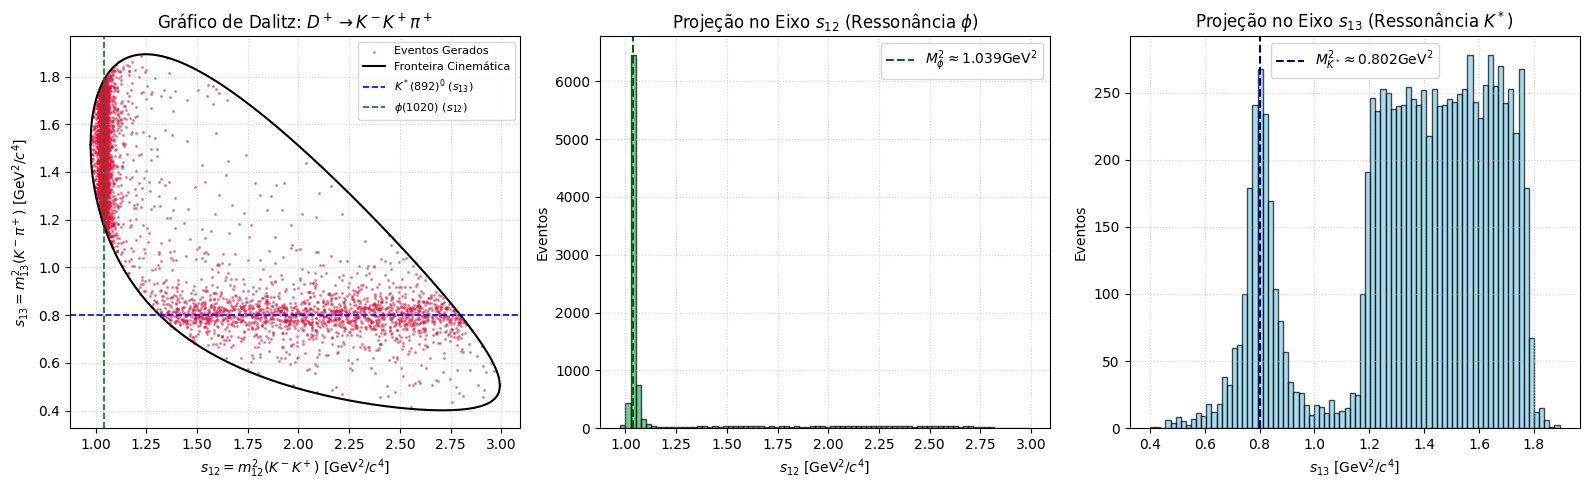

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. MASSAS DOS PARÂMETROS (em GeV/c^2) ---
M  = 1.86966   # D+
m1 = 0.49368   # K-  (1)
m2 = 0.49368   # K+  (2)
m3 = 0.13957   # pi+ (3)

# Ressonância 1: K*(892)0 no canal s13 (K- pi+)
M_Kstar     = 0.89555   # GeV/c^2
Gamma_Kstar = 0.0473    # GeV (47.3 MeV)

# Ressonância 2: phi(1020) no canal s12 (K- K+)
M_phi     = 1.019461  # GeV/c^2
Gamma_phi = 0.004249  # GeV (4.25 MeV)

# --- 2. LIMITES DO RETÂNGULO GERADOR ---
s12_min = (m1 + m2)**2
s12_max = (M - m3)**2
s13_min_box = (m1 + m3)**2
s13_max_box = (M - m2)**2

def get_s13_bounds(s12, M, m1, m2, m3):
    """Limites cinemáticos s13(s12)"""
    E1_star = (s12 + m1**2 - m2**2) / (2.0 * np.sqrt(s12))
    E3_star = (M**2 - s12 - m3**2) / (2.0 * np.sqrt(s12))

    p1_star = np.sqrt(np.maximum(0.0, E1_star**2 - m1**2))
    p3_star = np.sqrt(np.maximum(0.0, E3_star**2 - m3**2))

    s13_low = m1**2 + m3**2 + 2.0 * E1_star * E3_star - 2.0 * p1_star * p3_star
    s13_up  = m1**2 + m3**2 + 2.0 * E1_star * E3_star + 2.0 * p1_star * p3_star
    return s13_low, s13_up

# --- 3. INTENSIDADES E PDF TOTAL ---
def bw_pdf_s13(s13):
    """|A_K*|^2 no canal s13"""
    return 1.0 / ((s13 - M_Kstar**2)**2 + (M_Kstar * Gamma_Kstar)**2)

def bw_pdf_s12(s12):
    """|A_phi|^2 no canal s12"""
    return 1.0 / ((s12 - M_phi**2)**2 + (M_phi * Gamma_phi)**2)

def pdf_total(s12, s13):
    """Soma dos módulos ao quadrado das duas amplitudes"""
    return bw_pdf_s13(s13) + bw_pdf_s12(s12)

# Peso máximo global no ponto de interseção teórica
w_max = bw_pdf_s13(M_Kstar**2) + bw_pdf_s12(M_phi**2)

# --- 4. GERAÇÃO MONTE CARLO POR ACEITAÇÃO/REJEIÇÃO ---
n_eventos_desejados = 10000
s12_aceitos, s13_aceitos = [], []

np.random.seed(42)

while len(s12_aceitos) < n_eventos_desejados:
    # Lote ampliado para compensar a largura muito fina do phi
    lote = (n_eventos_desejados - len(s12_aceitos)) * 60
    s12_cand = np.random.uniform(s12_min, s12_max, lote)
    s13_cand = np.random.uniform(s13_min_box, s13_max_box, lote)

    # 1. Filtro cinemático de Dalitz
    s13_low, s13_up = get_s13_bounds(s12_cand, M, m1, m2, m3)
    mask_kin = (s13_cand >= s13_low) & (s13_cand <= s13_up)

    s12_kin = s12_cand[mask_kin]
    s13_kin = s13_cand[mask_kin]

    # 2. Pesagem pela PDF Total
    weights = pdf_total(s12_kin, s13_kin)
    u = np.random.uniform(0, w_max, len(s13_kin))
    mask_pdf = u <= weights

    s12_aceitos.extend(s12_kin[mask_pdf])
    s13_aceitos.extend(s13_kin[mask_pdf])

s12_aceitos = np.array(s12_aceitos[:n_eventos_desejados])
s13_aceitos = np.array(s13_aceitos[:n_eventos_desejados])

print(f"Sucesso! Gerados {len(s12_aceitos)} eventos com as ressonâncias K*(892) e phi(1020).")

# --- 5. VISUALIZAÇÃO GRÁFICA (2D Dalitz + 1D Projeções) ---
fig = plt.figure(figsize=(16, 5))

# Gráfico 1: Dalitz 2D
ax1 = fig.add_subplot(1, 3, 1)
s12_grid = np.linspace(s12_min + 1e-6, s12_max - 1e-6, 500)
s13_low_grid, s13_up_grid = get_s13_bounds(s12_grid, M, m1, m2, m3)

ax1.scatter(s12_aceitos, s13_aceitos, color='crimson', s=1.5, alpha=0.4, label='Eventos Gerados')
ax1.plot(s12_grid, s13_low_grid, 'k-', linewidth=1.5)
ax1.plot(s12_grid, s13_up_grid, 'k-', linewidth=1.5, label='Fronteira Cinemática')

# Indicação das posições das ressonâncias
ax1.axhline(M_Kstar**2, color='blue', linestyle='--', linewidth=1.2, label=r'$K^*(892)^0$ ($s_{13}$)')
ax1.axvline(M_phi**2, color='green', linestyle='--', linewidth=1.2, label=r'$\phi(1020)$ ($s_{12}$)')

ax1.set_title(r'Gráfico de Dalitz: $D^+ \to K^- K^+ \pi^+$', fontsize=12)
ax1.set_xlabel(r'$s_{12} = m_{12}^2 (K^- K^+)$ [$\mathrm{GeV}^2/c^4$]', fontsize=10)
ax1.set_ylabel(r'$s_{13} = m_{13}^2 (K^- \pi^+)$ [$\mathrm{GeV}^2/c^4$]', fontsize=10)
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, linestyle=':', alpha=0.5)

# Gráfico 2: Projeção s12 (Pico do Phi)
ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(s12_aceitos, bins=80, range=(s12_min, s12_max), color='mediumseagreen', edgecolor='black', alpha=0.7)
ax2.axvline(M_phi**2, color='darkgreen', linestyle='--', linewidth=1.5, label=r'$M_\phi^2 \approx 1.039 \mathrm{GeV}^2$')
ax2.set_title(r'Projeção no Eixo $s_{12}$ (Ressonância $\phi$)', fontsize=12)
ax2.set_xlabel(r'$s_{12}$ [$\mathrm{GeV}^2/c^4$]', fontsize=10)
ax2.set_ylabel('Eventos', fontsize=10)
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

# Gráfico 3: Projeção s13 (Pico do K*)
ax3 = fig.add_subplot(1, 3, 3)
ax3.hist(s13_aceitos, bins=80, range=(s13_min_box, s13_max_box), color='skyblue', edgecolor='black', alpha=0.7)
ax3.axvline(M_Kstar**2, color='navy', linestyle='--', linewidth=1.5, label=r'$M_{K^*}^2 \approx 0.802 \mathrm{GeV}^2$')
ax3.set_title(r'Projeção no Eixo $s_{13}$ (Ressonância $K^*$)', fontsize=12)
ax3.set_xlabel(r'$s_{13}$ [$\mathrm{GeV}^2/c^4$]', fontsize=10)
ax3.set_ylabel('Eventos', fontsize=10)
ax3.legend()
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Diagrama de Dalitz e Projeções no eixo s12 e s13 com Ressonâncias $K^*(892)^0$ e $\phi(1020)$ com distribuição angular (spin 1)

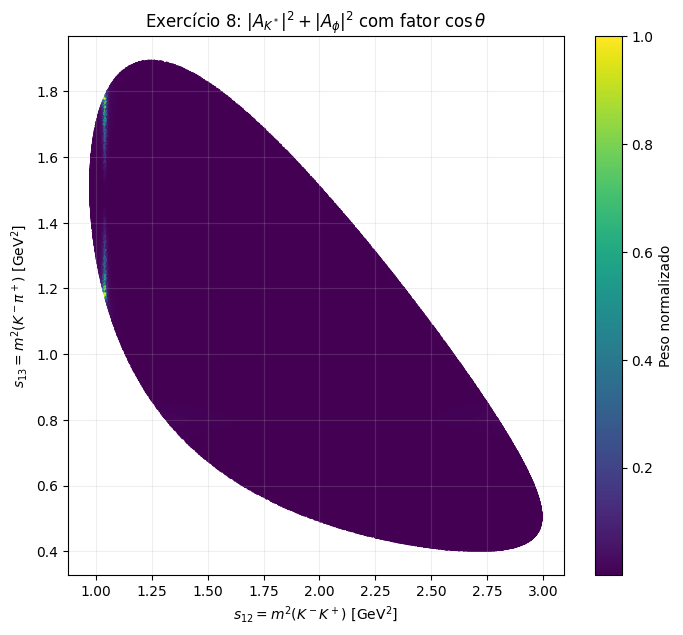

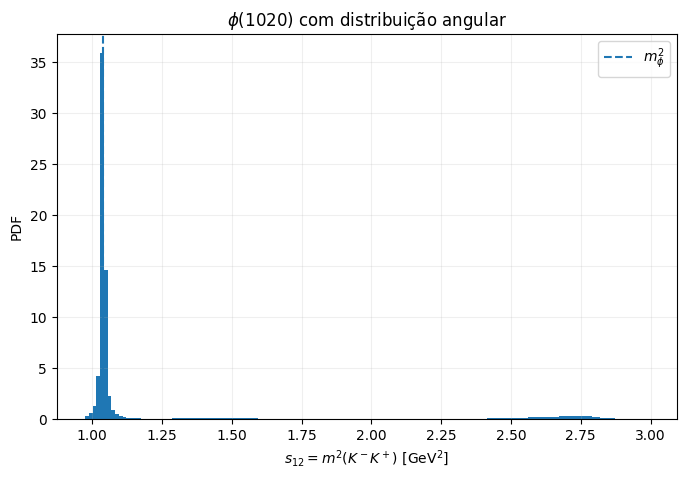

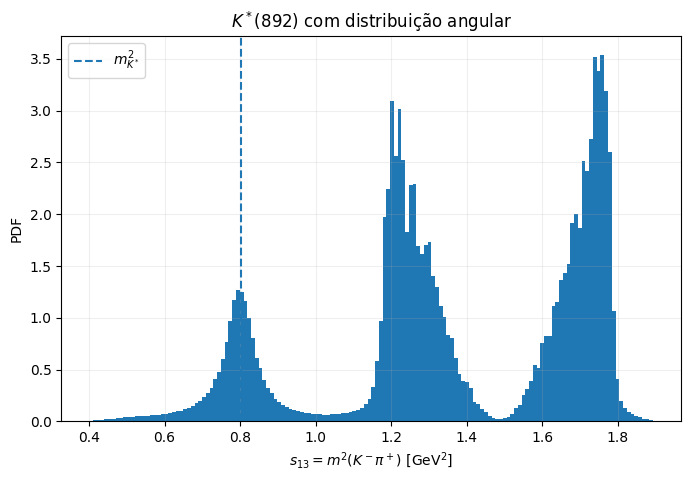

EXERCICIO 8
K*(892):
massa   = 0.895550 GeV
largura = 0.047300 GeV

phi(1020):
massa   = 1.019461 GeV
largura = 0.004249 GeV

Amplitudes:
A_K* = BW_K* * cos(theta_K*)
A_phi = BW_phi * cos(theta_phi)

PDF total:
P = |A_K*|^2 + |A_phi|^2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# MASSAS
# D+ -> K- K+ pi+
# ============================================================

M  = 1.86966       # D+ [GeV]

m1 = 0.493677      # K-
m2 = 0.493677      # K+
m3 = 0.139570      # pi+


# ============================================================
# PARAMETROS DAS RESSONANCIAS
# ============================================================

# K*(892)^0 -> K- pi+
m_Kstar = 0.89555
Gamma_Kstar = 0.0473

# phi(1020) -> K- K+
m_phi = 1.019461
Gamma_phi = 0.004249


# ============================================================
# BREIT-WIGNER
# ============================================================

def Breit_Wigner(s, m, Gamma):

    return 1.0 / (
        m**2 - s - 1j * m * Gamma
    )


# ============================================================
# LIMITES CINEMATICOS
# ============================================================

s12_min = (m1 + m2)**2
s12_max = (M - m3)**2


# ============================================================
# LIMITES DE s13 PARA UM DADO s12
# ============================================================

def s13_limits(s12):

    sqrt_s12 = np.sqrt(s12)

    E1 = (
        s12 + m1**2 - m2**2
    ) / (2 * sqrt_s12)

    E3 = (
        M**2 - s12 - m3**2
    ) / (2 * sqrt_s12)

    p1_squared = E1**2 - m1**2
    p3_squared = E3**2 - m3**2

    if p1_squared < 0 or p3_squared < 0:
        return None, None

    p1 = np.sqrt(p1_squared)
    p3 = np.sqrt(p3_squared)

    center = (
        m1**2
        + m3**2
        + 2 * E1 * E3
    )

    delta = 2 * p1 * p3

    return center - delta, center + delta


# ============================================================
# CALCULO DE cos(theta)
#
# Aqui usamos a relacao entre s12 e s13.
#
# Para um estado intermediario 12:
#
# s13 = m1² + m3² + 2(E1 E3 - p1 p3 cos(theta))
#
# portanto:
#
# cos(theta) =
# (m1² + m3² + 2 E1 E3 - s13)
# --------------------------------
#             2 p1 p3
# ============================================================

def cos_theta_12(s12, s13):

    sqrt_s12 = np.sqrt(s12)

    E1 = (
        s12 + m1**2 - m2**2
    ) / (2 * sqrt_s12)

    E3 = (
        M**2 - s12 - m3**2
    ) / (2 * sqrt_s12)

    p1_squared = E1**2 - m1**2
    p3_squared = E3**2 - m3**2

    if p1_squared <= 0 or p3_squared <= 0:
        return 0.0

    p1 = np.sqrt(p1_squared)
    p3 = np.sqrt(p3_squared)

    cos_theta = (
        m1**2
        + m3**2
        + 2 * E1 * E3
        - s13
    ) / (2 * p1 * p3)

    return np.clip(cos_theta, -1.0, 1.0)


# ============================================================
# CALCULO DE cos(theta) PARA O K*
#
# O K* está no sistema 13:
#
# s13 = m(K- pi+)²
#
# Para obter o angulo usamos s12 como a
# variavel complementar.
# ============================================================

def cos_theta_Kstar(s12, s13):

    sqrt_s13 = np.sqrt(s13)

    # Particula 1 = K-
    E1 = (
        s13 + m1**2 - m3**2
    ) / (2 * sqrt_s13)

    # Particula 2 = K+
    E2 = (
        M**2 - s13 - m2**2
    ) / (2 * sqrt_s13)

    p1_squared = E1**2 - m1**2
    p2_squared = E2**2 - m2**2

    if p1_squared <= 0 or p2_squared <= 0:
        return 0.0

    p1 = np.sqrt(p1_squared)
    p2 = np.sqrt(p2_squared)

    cos_theta = (
        m1**2
        + m2**2
        + 2 * E1 * E2
        - s12
    ) / (2 * p1 * p2)

    return np.clip(cos_theta, -1.0, 1.0)


# ============================================================
# AMPLITUDE DO K*
#
# Exercício 8:
#
# A_K* = BW_K* x cos(theta_K*)
# ============================================================

def A_Kstar(s12, s13):

    BW = Breit_Wigner(
        s13,
        m_Kstar,
        Gamma_Kstar
    )

    cos_theta = cos_theta_Kstar(
        s12,
        s13
    )

    return BW * cos_theta


# ============================================================
# AMPLITUDE DA PHI
#
# A_phi = BW_phi x cos(theta_phi)
# ============================================================

def A_phi(s12, s13):

    BW = Breit_Wigner(
        s12,
        m_phi,
        Gamma_phi
    )

    cos_theta = cos_theta_12(
        s12,
        s13
    )

    return BW * cos_theta


# ============================================================
# PDF TOTAL
#
# P = |A_K*|² + |A_phi|²
#
# SEM INTERFERENCIA
# ============================================================

def PDF_total(s12, s13):

    AK = A_Kstar(
        s12,
        s13
    )

    AP = A_phi(
        s12,
        s13
    )

    return (
        np.abs(AK)**2
        +
        np.abs(AP)**2
    )


# ============================================================
# MONTE CARLO
# ============================================================

N = 500000

rng = np.random.default_rng(12345)

s12_events = []
s13_events = []
weights = []


while len(s12_events) < N:

    # Sorteia s12
    s12 = rng.uniform(
        s12_min,
        s12_max
    )

    # Limites cinematicos de s13
    s13_low, s13_high = s13_limits(s12)

    if s13_low is None:
        continue

    # Sorteia s13
    s13 = rng.uniform(
        s13_low,
        s13_high
    )

    # PDF
    weight = PDF_total(
        s12,
        s13
    )

    s12_events.append(s12)
    s13_events.append(s13)
    weights.append(weight)


# ============================================================
# CONVERTE PARA NUMPY
# ============================================================

s12_events = np.array(s12_events)
s13_events = np.array(s13_events)
weights = np.array(weights)


# ============================================================
# NORMALIZACAO
# ============================================================

weights = weights / np.max(weights)


# ============================================================
# DALITZ PLOT
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    s12_events,
    s13_events,
    c=weights,
    s=0.5,
    cmap="viridis"
)

plt.xlabel(
    r"$s_{12}=m^2(K^-K^+)$ [GeV$^2$]"
)

plt.ylabel(
    r"$s_{13}=m^2(K^-\pi^+)$ [GeV$^2$]"
)

plt.title(
    r"Exercício 8: "
    r"$|A_{K^*}|^2+|A_{\phi}|^2$ "
    r"com fator $\cos\theta$"
)

plt.colorbar(
    label="Peso normalizado"
)

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# HISTOGRAMA s12
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    s12_events,
    bins=150,
    weights=weights,
    density=True
)

plt.axvline(
    m_phi**2,
    linestyle="--",
    label=r"$m_\phi^2$"
)

plt.xlabel(
    r"$s_{12}=m^2(K^-K^+)$ [GeV$^2$]"
)

plt.ylabel("PDF")

plt.title(
    r"$\phi(1020)$ com distribuição angular"
)

plt.legend()

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# HISTOGRAMA s13
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    s13_events,
    bins=150,
    weights=weights,
    density=True
)

plt.axvline(
    m_Kstar**2,
    linestyle="--",
    label=r"$m_{K^*}^2$"
)

plt.xlabel(
    r"$s_{13}=m^2(K^-\pi^+)$ [GeV$^2$]"
)

plt.ylabel("PDF")

plt.title(
    r"$K^*(892)$ com distribuição angular"
)

plt.legend()

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# INFORMACOES
# ============================================================

print("==============================================")
print("EXERCICIO 8")
print("==============================================")

print("K*(892):")
print(f"massa   = {m_Kstar:.6f} GeV")
print(f"largura = {Gamma_Kstar:.6f} GeV")

print()
print("phi(1020):")
print(f"massa   = {m_phi:.6f} GeV")
print(f"largura = {Gamma_phi:.6f} GeV")

print()
print("Amplitudes:")
print("A_K* = BW_K* * cos(theta_K*)")
print("A_phi = BW_phi * cos(theta_phi)")

print()
print("PDF total:")
print("P = |A_K*|^2 + |A_phi|^2")

print("==============================================")

# Diagrama de Dalitz e Projeções no eixo s12 e s13 com Ressonâncias $K^*(892)^0$ e $\phi(1020)$ com distribuição angular (spin 1) e agregando interferências

EVENTOS GERADOS
N = 300000


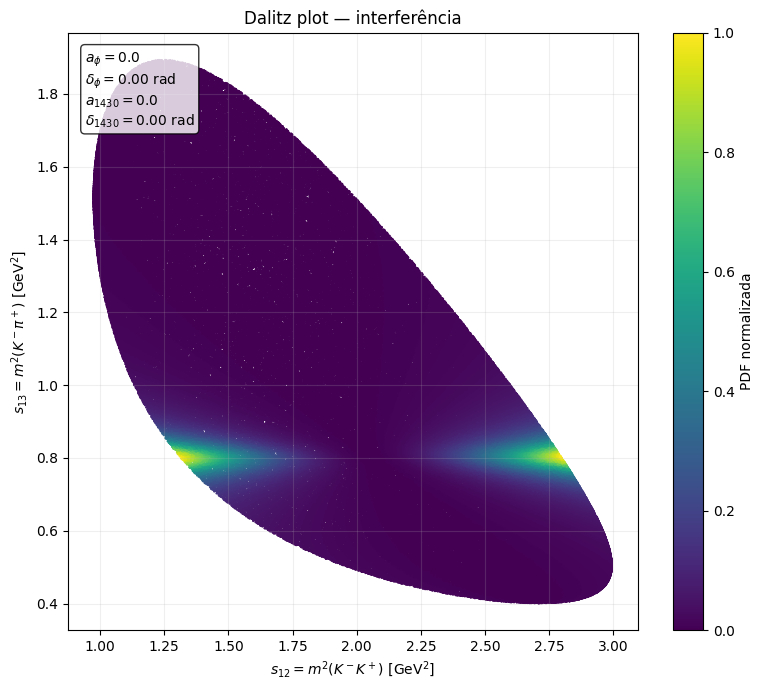

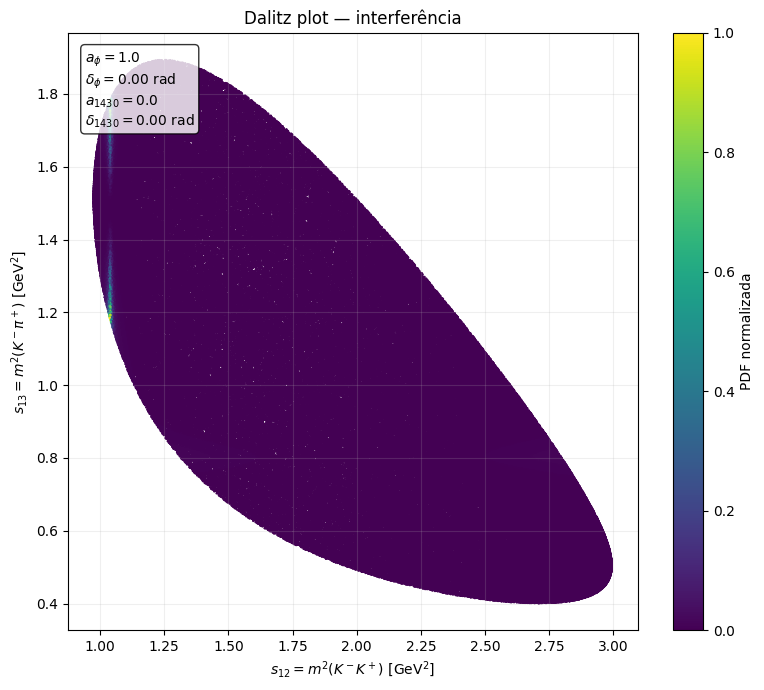

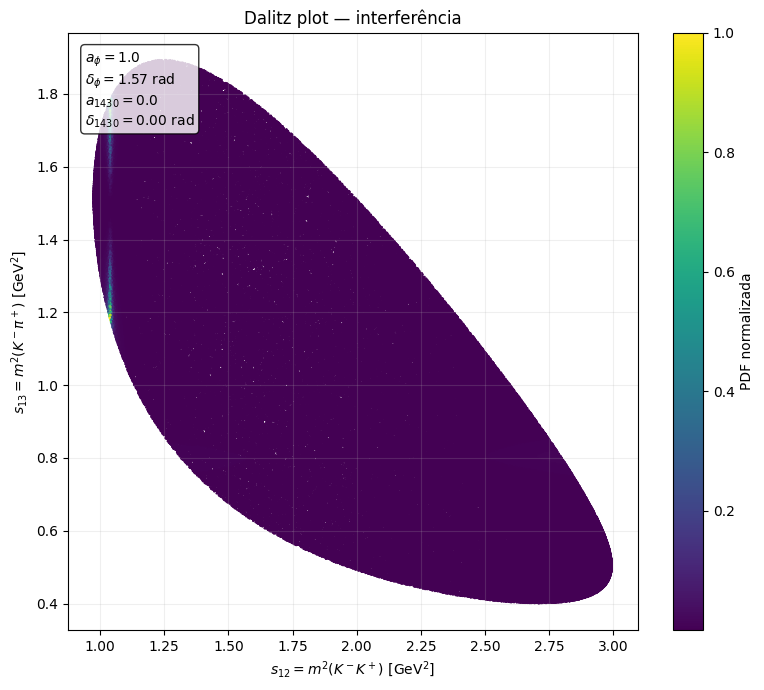

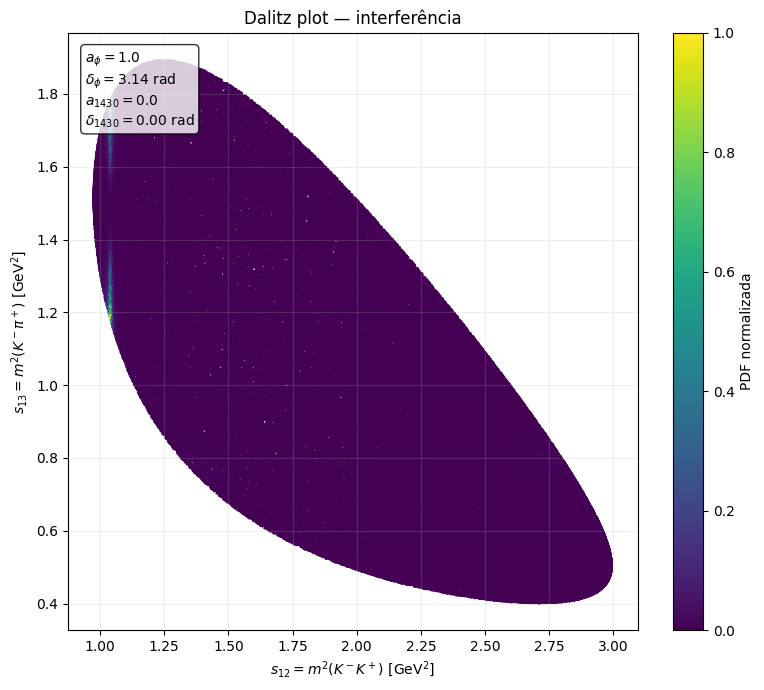

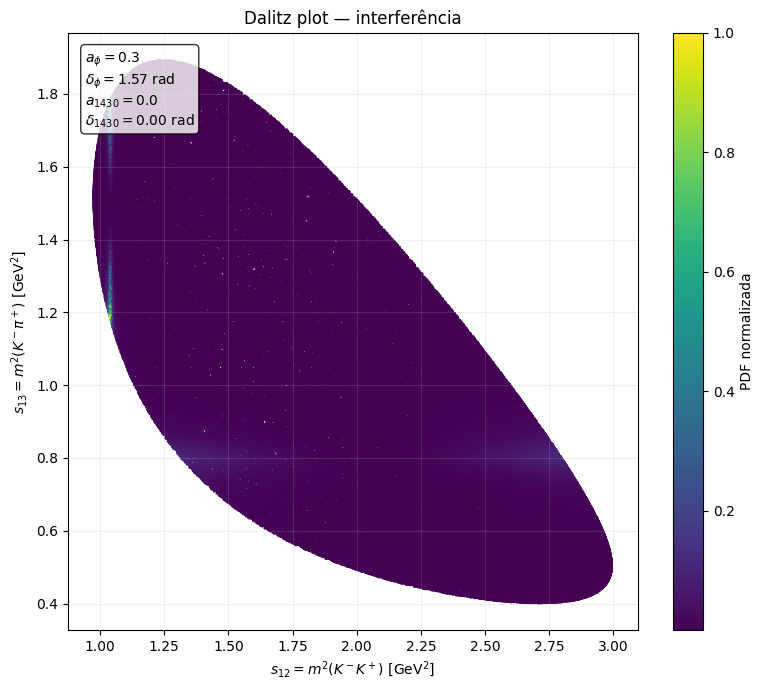

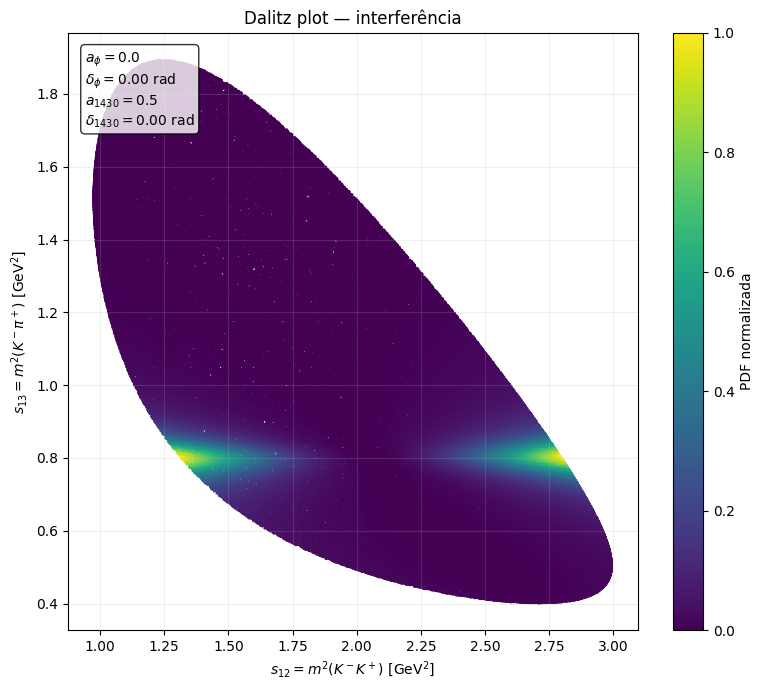

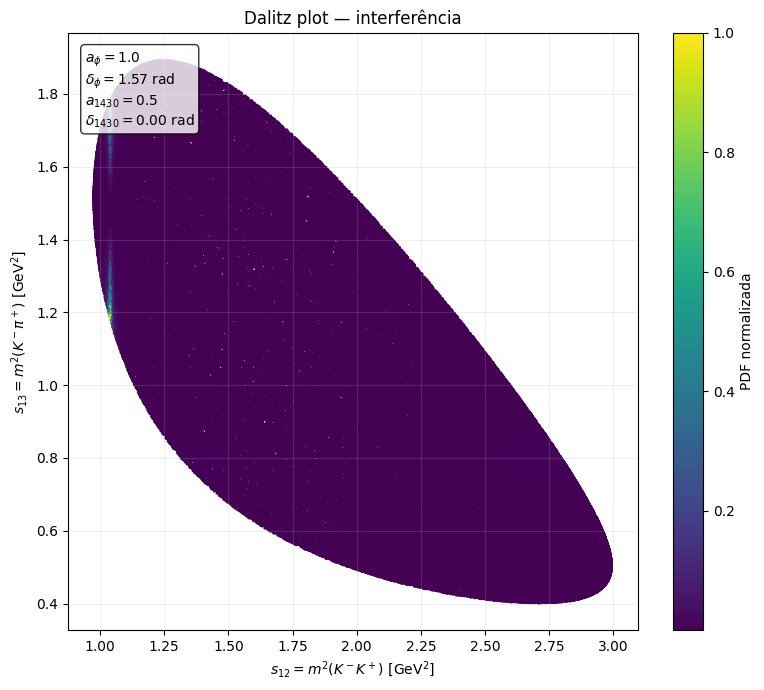

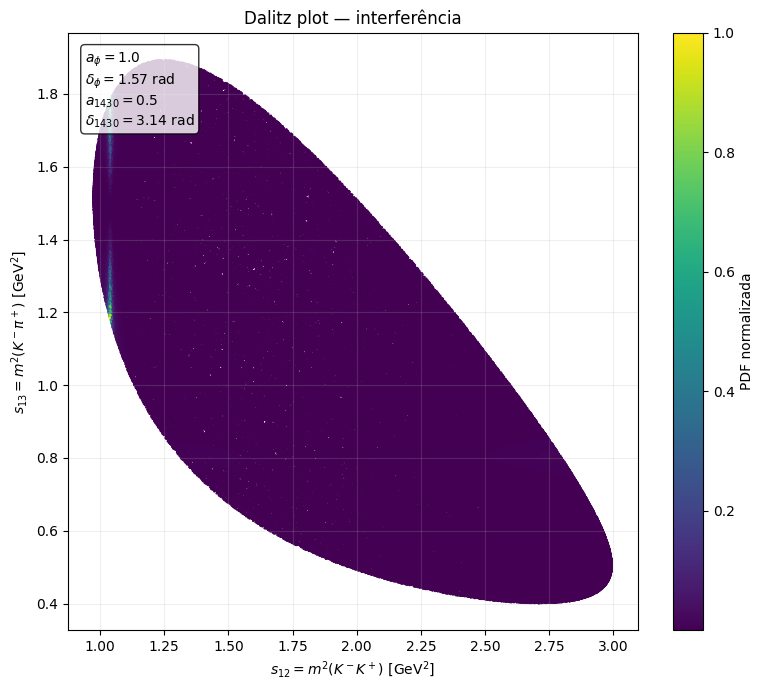

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# EXERCICIO 9
#
# D+ -> K- K+ pi+
#
# Interferencia entre:
#
# K*(892)  -> K- pi+     (s13)
# phi(1020) -> K- K+     (s12)
# K*(1430) -> K- pi+     (s13)
#
# A_total =
#
# A_Kstar
# + a_phi exp(i delta_phi) A_phi
# + a_1430 exp(i delta_1430) A_Kstar1430
#
# PDF = |A_total|^2
# ============================================================


# ============================================================
# 1. MASSAS DO DECAIMENTO
# ============================================================

M = 1.86966          # D+ [GeV]

mK  = 0.493677       # K [GeV]
mpi = 0.139570       # pi [GeV]


# ============================================================
# 2. PARAMETROS DAS RESSONANCIAS
# ============================================================

# ------------------------------------------------------------
# K*(892)
# ------------------------------------------------------------

m_Kstar = 0.89555
Gamma_Kstar = 0.0473


# ------------------------------------------------------------
# phi(1020)
# ------------------------------------------------------------

m_phi = 1.019461
Gamma_phi = 0.004249


# ------------------------------------------------------------
# K*(1430)
#
# Valores de referencia.
# Podem ser alterados conforme os parametros que voce estiver
# usando no PDG/Kajantie.
# ------------------------------------------------------------

m_Kstar1430 = 1.414
Gamma_Kstar1430 = 0.232


# ============================================================
# 3. BREIT-WIGNER
#
# Largura constante
# ============================================================

def Breit_Wigner(s, m, Gamma):

    return 1.0 / (
        m**2 - s - 1j * m * Gamma
    )


# ============================================================
# 4. LIMITES DE s12
#
# s12 = m²(K- K+)
# ============================================================

s12_min = (2.0 * mK)**2
s12_max = (M - mpi)**2


# ============================================================
# 5. LIMITES CINEMATICOS DE s13
#
# Para um dado s12
# ============================================================

def s13_limits(s12):

    sqrt_s12 = np.sqrt(s12)

    # K- no sistema K-K+
    E1 = (
        s12 + mK**2 - mK**2
    ) / (2.0 * sqrt_s12)

    # pi no sistema K-K+
    E3 = (
        M**2 - s12 - mpi**2
    ) / (2.0 * sqrt_s12)

    p1_squared = E1**2 - mK**2
    p3_squared = E3**2 - mpi**2

    p1 = np.sqrt(
        np.maximum(p1_squared, 0.0)
    )

    p3 = np.sqrt(
        np.maximum(p3_squared, 0.0)
    )

    center = (
        mK**2
        + mpi**2
        + 2.0 * E1 * E3
    )

    delta = 2.0 * p1 * p3

    s13_low = center - delta
    s13_high = center + delta

    return s13_low, s13_high


# ============================================================
# 6. cos(theta_phi)
#
# A phi está no sistema 12 = K- K+
#
# theta_phi:
# angulo entre K- e o pi no referencial do sistema K-K+
# ============================================================

def cos_theta_phi(s12, s13):

    sqrt_s12 = np.sqrt(s12)

    E1 = (
        s12 + mK**2 - mK**2
    ) / (2.0 * sqrt_s12)

    E3 = (
        M**2 - s12 - mpi**2
    ) / (2.0 * sqrt_s12)

    p1_squared = E1**2 - mK**2
    p3_squared = E3**2 - mpi**2

    p1 = np.sqrt(
        np.maximum(p1_squared, 1e-15)
    )

    p3 = np.sqrt(
        np.maximum(p3_squared, 1e-15)
    )

    numerator = (
        mK**2
        + mpi**2
        + 2.0 * E1 * E3
        - s13
    )

    denominator = 2.0 * p1 * p3

    cos_theta = numerator / denominator

    return np.clip(
        cos_theta,
        -1.0,
        1.0
    )


# ============================================================
# 7. cos(theta_Kstar)
#
# K* está no sistema 13 = K- pi+
#
# theta_Kstar:
# angulo entre K- e o K+ no referencial K-pi+
# ============================================================

def cos_theta_Kstar(s12, s13):

    sqrt_s13 = np.sqrt(s13)

    # K- no sistema K-pi
    E1 = (
        s13 + mK**2 - mpi**2
    ) / (2.0 * sqrt_s13)

    # K+ = partícula espectadora
    E2 = (
        M**2 - s13 - mK**2
    ) / (2.0 * sqrt_s13)

    p1_squared = E1**2 - mK**2
    p2_squared = E2**2 - mK**2

    p1 = np.sqrt(
        np.maximum(p1_squared, 1e-15)
    )

    p2 = np.sqrt(
        np.maximum(p2_squared, 1e-15)
    )

    numerator = (
        mK**2
        + mK**2
        + 2.0 * E1 * E2
        - s12
    )

    denominator = 2.0 * p1 * p2

    cos_theta = numerator / denominator

    return np.clip(
        cos_theta,
        -1.0,
        1.0
    )


# ============================================================
# 8. AMPLITUDE K*(892)
#
# A_K* = BW_K* x cos(theta_K*)
# ============================================================

def A_Kstar(s12, s13):

    BW = Breit_Wigner(
        s13,
        m_Kstar,
        Gamma_Kstar
    )

    angular = cos_theta_Kstar(
        s12,
        s13
    )

    return BW * angular


# ============================================================
# 9. AMPLITUDE PHI
#
# A_phi = BW_phi x cos(theta_phi)
# ============================================================

def A_phi(s12, s13):

    BW = Breit_Wigner(
        s12,
        m_phi,
        Gamma_phi
    )

    angular = cos_theta_phi(
        s12,
        s13
    )

    return BW * angular


# ============================================================
# 10. AMPLITUDE K*(1430)
#
# Mesmo sistema do K*(892):
#
# s13 = m²(K- pi+)
# ============================================================

def A_Kstar1430(s12, s13):

    BW = Breit_Wigner(
        s13,
        m_Kstar1430,
        Gamma_Kstar1430
    )

    angular = cos_theta_Kstar(
        s12,
        s13
    )

    return BW * angular


# ============================================================
# 11. AMPLITUDE TOTAL
#
# A_total =
#
# A_Kstar
# + a_phi exp(i delta_phi) A_phi
# + a_1430 exp(i delta_1430) A_Kstar1430
# ============================================================

def amplitude_total(
    s12,
    s13,
    a_phi=0.0,
    delta_phi=0.0,
    a_1430=0.0,
    delta_1430=0.0
):

    AK = A_Kstar(
        s12,
        s13
    )

    AP = A_phi(
        s12,
        s13
    )

    AK1430 = A_Kstar1430(
        s12,
        s13
    )

    A_total = (
        AK
        + a_phi
        * np.exp(1j * delta_phi)
        * AP
        + a_1430
        * np.exp(1j * delta_1430)
        * AK1430
    )

    return A_total


# ============================================================
# 12. PDF TOTAL
#
# PDF = |A_total|²
# ============================================================

def PDF_total(
    s12,
    s13,
    a_phi=0.0,
    delta_phi=0.0,
    a_1430=0.0,
    delta_1430=0.0
):

    A = amplitude_total(
        s12,
        s13,
        a_phi,
        delta_phi,
        a_1430,
        delta_1430
    )

    return np.abs(A)**2


# ============================================================
# 13. GERACAO VETORIZADA DOS EVENTOS
# ============================================================

N = 300000

rng = np.random.default_rng(12345)

s12_list = []
s13_list = []

N_gerados = 0

# Geramos blocos grandes de eventos
# para evitar um while evento por evento.

while N_gerados < N:

    N_batch = max(
        100000,
        2 * (N - N_gerados)
    )

    # Sorteia s12
    s12_batch = rng.uniform(
        s12_min,
        s12_max,
        N_batch
    )

    # Limites cinematicos
    s13_low, s13_high = s13_limits(
        s12_batch
    )

    # Sorteia s13 dentro da região permitida
    s13_batch = rng.uniform(
        s13_low,
        s13_high
    )

    # Todos os pontos já são cinematicamente permitidos
    s12_list.append(s12_batch)
    s13_list.append(s13_batch)

    N_gerados += N_batch


# Junta tudo
s12_events = np.concatenate(s12_list)
s13_events = np.concatenate(s13_list)

# Mantém exatamente N eventos
s12_events = s12_events[:N]
s13_events = s13_events[:N]


print("============================================")
print("EVENTOS GERADOS")
print("============================================")
print(f"N = {len(s12_events)}")


# ============================================================
# 14. FUNCAO PARA PLOTAR O DALITZ
# ============================================================

def plot_dalitz(
    a_phi=0.0,
    delta_phi=0.0,
    a_1430=0.0,
    delta_1430=0.0
):

    weights = PDF_total(
        s12_events,
        s13_events,
        a_phi=a_phi,
        delta_phi=delta_phi,
        a_1430=a_1430,
        delta_1430=delta_1430
    )

    # Normalização apenas para visualização
    weights = (
        weights / np.max(weights)
    )

    plt.figure(
        figsize=(8, 7)
    )

    plt.scatter(
        s12_events,
        s13_events,
        c=weights,
        s=0.5,
        cmap="viridis",
        rasterized=True
    )

    plt.xlabel(
        r"$s_{12}=m^2(K^-K^+)$ [GeV$^2$]"
    )

    plt.ylabel(
        r"$s_{13}=m^2(K^-\pi^+)$ [GeV$^2$]"
    )

    plt.title(
        r"Dalitz plot — interferência"
    )

    plt.colorbar(
        label="PDF normalizada"
    )

    plt.text(
        0.03,
        0.97,
        rf"$a_\phi={a_phi}$" "\n"
        rf"$\delta_\phi={delta_phi:.2f}$ rad" "\n"
        rf"$a_{{1430}}={a_1430}$" "\n"
        rf"$\delta_{{1430}}={delta_1430:.2f}$ rad",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 15. CASO 1
#
# SOMENTE K*(892)
#
# a_phi = 0
# a_1430 = 0
# ============================================================

plot_dalitz(
    a_phi=0.0,
    delta_phi=0.0,
    a_1430=0.0,
    delta_1430=0.0
)


# ============================================================
# 16. CASO 2
#
# K*(892) + phi
#
# FASE 0
# ============================================================

plot_dalitz(
    a_phi=1.0,
    delta_phi=0.0,
    a_1430=0.0,
    delta_1430=0.0
)


# ============================================================
# 17. CASO 3
#
# K*(892) + phi
#
# FASE pi/2
# ============================================================

plot_dalitz(
    a_phi=1.0,
    delta_phi=np.pi / 2,
    a_1430=0.0,
    delta_1430=0.0
)


# ============================================================
# 18. CASO 4
#
# K*(892) + phi
#
# FASE pi
# ============================================================

plot_dalitz(
    a_phi=1.0,
    delta_phi=np.pi,
    a_1430=0.0,
    delta_1430=0.0
)


# ============================================================
# 19. CASO 5
#
# PHI MAIS FRACA
# ============================================================

plot_dalitz(
    a_phi=0.3,
    delta_phi=np.pi / 2,
    a_1430=0.0,
    delta_1430=0.0
)


# ============================================================
# 20. CASO 6
#
# K*(892) + K*(1430)
#
# SEM PHI
# ============================================================

plot_dalitz(
    a_phi=0.0,
    delta_phi=0.0,
    a_1430=0.5,
    delta_1430=0.0
)


# ============================================================
# 21. CASO 7
#
# K*(892) + phi + K*(1430)
# ============================================================

plot_dalitz(
    a_phi=1.0,
    delta_phi=np.pi / 2,
    a_1430=0.5,
    delta_1430=0.0
)


# ============================================================
# 22. CASO 8
#
# ALTERANDO A FASE DO K*(1430)
# ============================================================

plot_dalitz(
    a_phi=1.0,
    delta_phi=np.pi / 2,
    a_1430=0.5,
    delta_1430=np.pi
)